In [169]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size ='5' color='black'>ch.11 데이터프레임과 시리즈</font>
- pip install pandas (아나콘다 프롬포트)

# 1. 판다스 패키지
- 데이터 분석을 위해 반드시 알아야할 패키지.
- 넘파이를 기반으로 하며, 다른 많은 라이브러리와 잘 통합되도록 설계됨.
<br>
- 1차원 구조 시리즈, 2차원 구조 데이터프레임 제공.
<br>
- 장점
```
데이터 프레임 생성 용이, 파일 i/o 간편화, 레이블링
부분 데이터 추출, 크기 변경(행/열 삽입 및 삭제 용이)
데이터 분할 및 병합, 데이터 정렬, 결측치 처리, 피벗/언피벗 용이
```

**참조**

판다스 독스 : [Pandas Docs.](https://pandas.pydata.org/docs/)
판다스 API 레퍼런스 : [Pandas API ref.](https://pandas.pydata.org/docs/reference/index.html)

In [6]:
import pandas as pd

pd.__version__

'1.5.3'

In [9]:
#pd.read() : 'encoding=' 기본값 : utf-8
data = pd.read_json('data/ch09_member1.json')
display(data)
print(type(data))

,name,age,email,address,job
0,홍길동,20,h@h.com,서울시 관악구,-
1,신길동,40,s@h.com,서울시 영등포구,팀장
2,김길동,30,k@h.com,서울시 동작구,-


<class 'pandas.core.frame.DataFrame'>


In [16]:
# 헤더가 있는 CSV
member3 = pd.read_csv('data/ch09_member3.csv')
member3

,name,age,email,address,job
0,홍길동,20,h@h.com,서울시 관악구,NaN
1,신길동,40,s@h.com,서울시 영등포구,팀장
2,김길동,30,k@h.com,서울시 동작구,NaN


In [17]:
# 헤더가 없는 CSV ; 헤더 설정 가능
member1 = pd.read_csv('data/ch09_member1.csv', 
                    header=None,
                    names=['이름', '나이', '이메일', '주소'] 
                     ) 
member1

,이름,나이,이메일,주소
0,홍길동,20,kildong@hong.com,서울시 관악구
1,김길동,40,kimdong@hong.com,서울시 영등포구
2,신길동,30,sindong@hong.com,서울시 동작구


In [18]:
pd.read_hdf('data/ch09_iris.h5', key='iris')

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# 2. 데이터 프레임 생성

## 2.1 딕셔너리를 이용한 데이터 프레임 생성                      

In [22]:
d = {'kor':[100,90], 'mat':[95,97]}
df = pd.DataFrame(data=d)
df

,kor,mat
0,100,95
1,90,97


In [26]:
# 데이터 프레임을 딕셔너리로
df.to_dict()

{'kor': {0: 100, 1: 90}, 'mat': {0: 95, 1: 97}}

In [27]:
# 데이터 프레임을 넘파이 배열으로
df.to_numpy()

array([[100,  95],
       [ 90,  97]], dtype=int64)

In [29]:
# 데이터 프레임은 열별로 동일 자료형을 가짐
d = [{'kor':100, 'mat':95},
    {'kor':90, 'mat':97.5}]
df = pd.DataFrame(d)
df

,kor,mat
0,100,95.0
1,90,97.5


In [32]:
# 데이터 프레임의 열별 타입
print(df.dtypes)
print()
# 데이터 프레임의 정보 확인
df.info()

kor      int64
mat    float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   kor     2 non-null      int64  
 1   mat     2 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 160.0 bytes


In [34]:
# 1차원 데이터 : 시리즈
type(df['kor'])

pandas.core.series.Series

In [35]:
# 데이터 프레임의 열 타입 변경
import numpy as np
df['kor'].astype(np.float64)

0    100.0
1     90.0
Name: kor, dtype: float64

In [36]:
# 열 인덱스에 맞추어 생성 및 결측치 처리
d = [{'kor':100, 'mat':100},{'kor':90, 'mat':95},{'kor':83,'eng':97}]
df = pd.DataFrame(d)
df

,kor,mat,eng
0,100,100.0,NaN
1,90,95.0,NaN
2,83,NaN,97.0


In [37]:
# 결측치의 type : float, 결측치가 있는 열은 float으로 처리됨
type(np.nan)

float

In [39]:
# 결측치는 int로 형변환이 불가함
df['mat'].astype('int32')

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

## 2.2 리스트를 이용한 데이터 프레임 생성

In [41]:
kor = [100,100,95,80,87]
mat = [80,90,65,80,75]
df = pd.DataFrame({'kor':kor, 'mat':mat})
df

,kor,mat
0,100,80
1,100,90
2,95,65
3,80,80
4,87,75


In [44]:
# 두 리스트를 np.c_처리하여 데이터 프레임 생성 및 columns를 통해 헤더 생성
pd.DataFrame(np.c_[kor, mat], columns=['kor', 'mat'])

,kor,mat
0,100,80
1,100,90
2,95,65
3,80,80
4,87,75


In [47]:
l = [[100, 90],[70, 80]]
pd.DataFrame(l, index=['철수', '영희'], columns=['국어','수학'])

,국어,수학
철수,100,90
영희,70,80


- data.go.kr : '상가 상권 정보' 다운로드 - '민간 아파트 분양 가격' 다운로드

In [50]:
%ls "C:/ai/downloads/shareData/상가정보/"

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 0C81-36F7

 C:\ai\downloads\shareData\상가정보 디렉터리

2026-07-08  오후 12:07    <DIR>          .
2026-07-14  오후 05:46    <DIR>          ..
2025-11-03  오전 12:45             1,011 [필독]파일열람방법.txt
2026-04-27  오전 11:10        61,321,696 소상공인시장진흥공단_상가(상권)정보_강원_202603.csv
2026-04-27  오전 11:10       367,852,181 소상공인시장진흥공단_상가(상권)정보_경기_202603.csv
2026-04-27  오전 11:10        92,474,293 소상공인시장진흥공단_상가(상권)정보_경남_202603.csv
2026-04-27  오전 11:10        76,309,810 소상공인시장진흥공단_상가(상권)정보_경북_202603.csv
2026-04-27  오전 11:10        40,031,721 소상공인시장진흥공단_상가(상권)정보_광주_202603.csv
2026-04-27  오전 11:10        61,825,564 소상공인시장진흥공단_상가(상권)정보_대구_202603.csv
2026-04-27  오전 11:10        41,866,930 소상공인시장진흥공단_상가(상권)정보_대전_202603.csv
2026-04-27  오전 11:10        84,329,596 소상공인시장진흥공단_상가(상권)정보_부산_202603.csv
2026-04-27  오전 11:10       292,646,735 소상공인시장진흥공단_상가(상권)정보_서울_202603.csv
2026-04-27  오전 11:10         9,651,297 소상공인시장진흥공단_상가(상권)정보_세종_202603.csv
2026-04-27  오전 11:10        28,285,232 소상공인시장진흥공단

In [56]:
df = pd.read_csv(r'C:/ai/downloads/shareData/상가정보/소상공인시장진흥공단_상가(상권)정보_세종_202603.csv',
                #encoding='utf-8', sep=',' : 기본값
                nrows = 30, # 첫 30행 불러오기
                low_memory=False, # 데이터 용량이 클 경우 사용
                )
df.shape # 데이터 프레임 크기

(30, 39)

In [55]:
df.head(1) # 상위 1행

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220813963449,레인카페,NaN,I2,음식,I212,비알코올,I21201,카페,I56229,...,4473025021101010001038753,NaN,세종특별자치시 세종특별자치시 조치원읍 조치원8길 16,339883.0,30027,NaN,지,NaN,127.300453,36.600906


In [60]:
# 데이터 프레임 디스플레이 옵션
pd.options.display.max_columns = 40 # 40열까지 display
pd.options.display.max_rows = 40 # 40행까지 display

In [63]:
df.head(3).T # 상위 3행을 전치

,0,1,2
상가업소번호,MA010120220813963449,MA010120220805872513,MA010120220700019175
상호명,레인카페,수와마을,세종수이비인후과의원
지점명,NaN,NaN,NaN
상권업종대분류코드,I2,I2,Q1
상권업종대분류명,음식,음식,보건의료
상권업종중분류코드,I212,I201,Q102
상권업종중분류명,비알코올,한식,의원
상권업종소분류코드,I21201,I20101,Q10201
상권업종소분류명,카페,백반/한정식,내과/소아과 의원
표준산업분류코드,I56229,I56111,Q86201


## 2.3 read_csv

- csv 파일 불러오기

In [21]:
# csv 파일 불러오기(기본값) : '#'을 생략하지 않음
import pandas as pd
member = pd.read_csv('data/ch11_member.csv')
member

,Name,Age,Email,Address,Birth
0,홍길동,20.0,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30.0,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21.0,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22.0,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23.0,mid@hong.com,부산시 중구,1999-01-30
5,#홍길뜽,NaN,non@not.com,없는구,2000-01-01


In [22]:
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Name     6 non-null      object 
 1   Age      5 non-null      float64
 2   Email    6 non-null      object 
 3   Address  6 non-null      object 
 4   Birth    6 non-null      object 
dtypes: float64(1), object(4)
memory usage: 368.0+ bytes


In [23]:
# 문자형으로 변환
member['Age'] = member['Age'].astype('str') # Out 출력이 있을 경우, 할당 필요

In [24]:
member['Age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 6 entries, 0 to 5
Series name: Age
Non-Null Count  Dtype 
--------------  ----- 
6 non-null      object
dtypes: object(1)
memory usage: 176.0+ bytes


In [25]:
member.loc[0, 'Age']

'20.0'

In [41]:
# 숫자형으로 변환
member['Age'] = pd.to_numeric(member['Age'], 
                              errors='coerce'
                             # 숫자로 바꿀 수 없는 값을 결측치(NaN)로 강제 변환
                             )
member['Age'] = member['Age'].astype('Int64')

member
# member['Age'].astype('int16')

# import numpy as np
# member['Age'].astype(np.float64)

,Name,Age,Email,Address,Birth,year,month,day
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1,1
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12,1
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11,1
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5,1
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1,30
5,#홍길뜽,<NA>,non@not.com,없는구,2000-01-01,2000,1,1


In [42]:
 pd.to_numeric(member['Age'], 
               downcast='integer',
               # Age의 문자열을 integer 중 적용 가능한 가장 작은 타입으로 형변환
               errors='ignore'
               # 숫자로 바꿀 수 없는 데이터(ex:3,000)는 원본 데이터를 그대로 반환 (object or 기존 타입)
              )
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Name     6 non-null      object        
 1   Age      5 non-null      Int64         
 2   Email    6 non-null      object        
 3   Address  6 non-null      object        
 4   Birth    6 non-null      datetime64[ns]
 5   year     6 non-null      int64         
 6   month    6 non-null      int64         
 7   day      6 non-null      int64         
dtypes: Int64(1), datetime64[ns](1), int64(3), object(3)
memory usage: 518.0+ bytes


In [37]:
# object로 읽어들인 Birth를 datetime형으로
member['Birth'] = member['Birth'].astype('datetime64[ns]') # 데이터 형태 : YYYY-MM-DD
member.astype({'Birth':'datetime64[ns]', 'Age':'Int32'})
pd.to_datetime(member['Birth'],
              #format='%Y-%m-%d %H:%M:%S'
              )
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Name     6 non-null      object        
 1   Age      5 non-null      Int64         
 2   Email    6 non-null      object        
 3   Address  6 non-null      object        
 4   Birth    6 non-null      datetime64[ns]
 5   year     6 non-null      int64         
 6   month    6 non-null      int64         
 7   day      6 non-null      int64         
dtypes: Int64(1), datetime64[ns](1), int64(3), object(3)
memory usage: 518.0+ bytes


In [38]:
# 날짜형 데이터의 년-월-일 분할
member['year'] = member.Birth.dt.year
member['month'] = member.Birth.dt.month
member['day'] = member.Birth.dt.day

In [39]:
member

,Name,Age,Email,Address,Birth,year,month,day
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1,1
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12,1
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11,1
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5,1
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1,30
5,#홍길뜽,<NA>,non@not.com,없는구,2000-01-01,2000,1,1


In [439]:
current_date = pd.to_datetime('2026-07-15')
member['일수'] = (current_date - member.Birth).dt.days
member

,Name,Age,Email,Address,Birth,일수
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,10057
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,9723
2,홍길남,21,NaN,서울시 강동구,1999-11-01,9753
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,9937
4,홍길중,23,NaN,부산시 중구,1999-01-30,10028


In [50]:
# 특정 행을 제외하고 cp949 파일 불러오기
member = pd.read_csv('data/ch11_membercp949.csv', 
                     encoding = 'cp949',
                    skiprows=[1,6] #1, 6 행 제외하고 불러오기
                    )
member

,Name,Age,Email,Address,Birth
0,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
1,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
2,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
3,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [53]:
# sep='|', 주석(#) 제외, 상위 n행, datetime형 필드 지정
member_df = pd.read_csv('data/ch11_membersep.csv',
                       sep='|', # '|' 기준으로 데이터를 분리해 읽기
                       comment='#', # 주석(#) 제외
                       nrows=3, # 상위 3행만 불러오기
                       parse_dates=['Birth']) # datetime형 필드 지정

member_df

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [55]:
member_df = pd.read_csv('data/ch11_membertab.csv',
                       sep='\t',
                       comment='#',
                       parse_dates=['Birth'])

member_df

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 2.4 패키지에서 가져오기
- 예시 : iris data 가져오기
    * 방법 1) sklearn (머신러닝 패키지)
    * 방법 2) statsmodels (R 데이터 패키지)
    * 방법 3) seaborn (시각화 패키지)
    
### 2.4.1 sklearn
- 머신러닝을 공부하기 위한 학습용 데이터셋 제공
    * sklearn pkg dataset : 독립변수(입력변수)와 종속변수(타겟변수)가 분리된 딕셔너리 형태로 제공
 - sklearn.datsets 모듈의 데이터를 데이터 프레임으로 변환

In [57]:
# sklearn을 통해 iris data 가져오기
from sklearn import datasets
iris = datasets.load_iris() # 딕셔너리 형태
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [58]:
#iris 데이터셋에 대한 설명
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [60]:
iris.data # 독립변수
iris['data'][:3]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [61]:
iris.feature_names # 독립변수의 열 이름(인덱스)

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [63]:
# 데이터프레임에서의 독립변수 열 이름 (' ' 또는 특수문자 '()' 사용 불가)
[col[:-5].replace(' ', '_') for col in iris.feature_names]

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [64]:
# 종속변수(타겟변수)
iris.target
iris['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [66]:
iris.target_names
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [68]:
# 데이터 프레임의 가장 오른쪽 열(타겟변수;species)
iris.target_names[iris.target]
iris['target_names'][iris['target']]

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [73]:
# 독립변수 [col[:-5].replace(' ', '_') for col in iris.feature_names]
data = iris.data
print(data[::50])
# 종속변수 species
target = iris.target_names[iris.target].reshape(-1, 1)
print(target[::50])

[[5.1 3.5 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.3 3.3 6.  2.5]]
[['setosa']
 ['versicolor']
 ['virginica']]


In [75]:
print('독립변수의 차원 수 :', data.shape)
print('종속변수의 차원 수 :', target.shape)

독립변수의 차원 수 : (150, 4)
종속변수의 차원 수 : (150, 1)


In [92]:
# 독립변수와 종속변수를 stack한 후, 데이터 프레임으로 생성
result = np.c_[data, target]
df = pd.DataFrame(result, columns=[col[:-5].replace(' ', '_') for col in iris.feature_names]+['species'])
df.head() # 기본값 : 상위 5행
df.tail() # 기본값 : 하위 5행

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [84]:
df['petal_width'][:3]
df.petal_width[:3]

0    0.2
1    0.2
2    0.2
Name: petal_width, dtype: object

In [85]:
df = pd.DataFrame(result, columns=iris.feature_names+['species'])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [87]:
# 열 이름에 띄워쓰기 또는 특수문자가 있을 경우
df['petal width (cm)'][:3]
# df.petal width (cm)[:3] 

0    0.2
1    0.2
2    0.2
Name: petal width (cm), dtype: object

In [90]:
# 독립변수와 종속변수를 각각 데이터 프레임으로 생성 후 두 데이터 프레임을 연결
# X : 독립변수 데이터 프레임 ; 변수 개수가 많을 경우 대문자 사용
X = pd.DataFrame(data, columns=[col[:-5].replace(' ','_') for col in iris.feature_names])
X.head(1)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


In [91]:
# y : 종속변수 데이터 프레임 ; 변수 개수가 하나일 경우 소문자 사용
y = pd.DataFrame(target, columns=['species'])
y.tail()

,species
145,virginica
146,virginica
147,virginica
148,virginica
149,virginica


In [93]:
print(X.index) # index : 행이름

RangeIndex(start=0, stop=150, step=1)


In [98]:
# 두 데이터 프레임을 연결 
iris_df = pd.concat([X, y],
                    axis = 1 # 기본값 : 0
                   )
iris_df[::25]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
25,5.0,3.0,1.6,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica
125,7.2,3.2,6.0,1.8,virginica


### 2.4.2 statsmodels

In [100]:
from statsmodels.api import datasets
iris_dataset = datasets.get_rdataset('iris',
                                    package='datasets',
                                    cache=True # 기본값 False ; 캐시 생성 없이 데이터를 불러옴 
                                    )          # True로 변경 ; 캐시 데이터를 PC에 저장
iris = iris_dataset.data
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [101]:
# 열 이름에 '.'이 있는 경우 "데이터프레임['열']" 형식만 사용 가능
iris['Sepal.Length'][:5]

0    5.1
1    4.9
2    4.7
3    4.6
4    5.0
Name: Sepal.Length, dtype: float64

In [105]:
# 열 이름 수정
iris.columns = [col.replace('.','_').lower() for col in iris.columns]
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2.4.3 seaborn

In [106]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [107]:
# 데이터 프레임을 파일로 출력
iris.to_csv('data/ch11_iris.csv') # 기본값 : sep=',', encoding='utf-8', index=True

In [109]:
# 행 이름이 추가되어 있음
pd.read_csv('data/ch11_iris.csv')[:5]

,Unnamed: 0,sepal_length,sepal_width,petal_length,petal_width,species
0,0,5.1,3.5,1.4,0.2,setosa
1,1,4.9,3.0,1.4,0.2,setosa
2,2,4.7,3.2,1.3,0.2,setosa
3,3,4.6,3.1,1.5,0.2,setosa
4,4,5.0,3.6,1.4,0.2,setosa


In [111]:
# 행 이름을 생략하여 파일로 출력
iris.to_csv('data/ch11_iris.csv', index=False)

In [112]:
# 파일을 압축하여 출력
iris.to_csv('data/ch11_iris.zip',
           index=False,
           compression='infer' # 파일 확장자(.zip, .gz, .bz2)를 확인 후 압축 형식을 따름
           )

In [114]:
load_iris = pd.read_csv('data/ch11_iris.csv')
load_iris.sample(3) # 임의의 3행 반환

,sepal_length,sepal_width,petal_length,petal_width,species
49,5.0,3.3,1.4,0.2,setosa
46,5.1,3.8,1.6,0.2,setosa
76,6.8,2.8,4.8,1.4,versicolor


In [115]:
load_iris = pd.read_csv('data/ch11_iris.zip', compression='infer')
load_iris.sample(3)

,sepal_length,sepal_width,petal_length,petal_width,species
107,7.3,2.9,6.3,1.8,virginica
81,5.5,2.4,3.7,1.0,versicolor
98,5.1,2.5,3.0,1.1,versicolor


# 3. 이름 지정하기

## 3.1 열 이름 지정

In [150]:
member = pd.read_csv('data/ch11_member.csv', comment='#', parse_dates=['Birth'])
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [151]:
# 열 이름 확인하기
member.columns

Index(['Name', 'Age', 'Email', 'Address', 'Birth'], dtype='object')

Index(['Name', 'Age', 'Email', 'Address', 'Birth'], dtype='object')
; column name's level  : 1

In [152]:
# 열 이름 지정하기
member.columns = ['성명', '나이', '이메일', '주소', '생일']
member

,성명,나이,이메일,주소,생일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 3.2 행 이름 지정

In [153]:
# 행 이름 확인하기
member.index

RangeIndex(start=0, stop=5, step=1)

In [154]:
# 행 이름 지정하기 1
member.index = range(1, 6)
member

,성명,나이,이메일,주소,생일
1,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
2,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
3,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
4,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
5,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [155]:
# 행 이름 지정하기 2
member.index = ['동', '서', '남', '북', '중']
member

,성명,나이,이메일,주소,생일
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [156]:
print(member.index)
print(member.index.name)

Index(['동', '서', '남', '북', '중'], dtype='object')
None


In [157]:
# ex) 이름을 행 이름(index)으로 지정하기
#     (1) 할당 (2) inplace 매개변수에 True (기본값 : False)
member.set_index('성명', inplace=True)
member

,나이,이메일,주소,생일
성명,,,,
홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
홍길서,30,seo@hong.com,서울시 중구,1999-12-01
홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [158]:
print(member.index)
print(member.columns) # 열 이름에서 '이름'열이 없어짐

Index(['홍길동', '홍길서', '홍길남', '홍길북', '홍길중'], dtype='object', name='성명')
Index(['나이', '이메일', '주소', '생일'], dtype='object')


In [160]:
# 행 이름(index)을 열에 편입하기
member.reset_index(inplace=True)

In [166]:
member.index=[0,4,1,2,3] # 나이순 sort()로 가정

In [168]:
# 기존 행 이름을 0부터 numbering (지양)
member.index = range(len(member))
member

,성명,나이,이메일,주소,생일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [171]:
# 기존 행 이름을 0부터 numbering (지향)
member.reset_index(drop=True, # 기존 행 이름을 열에 편입하지 않고 제거 후 숫자 index를 초기화
                   inplace=True)
member

,성명,나이,이메일,주소,생일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 3.3 레벨 이름 지정

In [172]:
print(member.columns)
print(member.columns.name)
display(member)

Index(['성명', '나이', '이메일', '주소', '생일'], dtype='object')
None


,성명,나이,이메일,주소,생일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [173]:
member.columns.name = '열 이름'
member

열 이름,성명,나이,이메일,주소,생일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [174]:
# 열 레벨이 2개 이상인 데이터 프레임 생성
member.columns = [['필수정보','필수정보','필수정보','선택정보','선택정보'],
                 ['성명', '나이', '이메일', '주소', '생년월일']]

In [183]:
member.columns.names = ['대분류','소분류']
member

대분류  필수정보                        선택정보           
소분류    성명  나이            이메일       주소       생년월일
좌우 동  홍길동  20  hong@hong.com  서울시 강동구 1999-01-01
   서  홍길서  30   seo@hong.com   서울시 중구 1999-12-01
상하 남  홍길남  21   nam@hong.com  서울시 강동구 1999-11-01
   북  홍길북  22   buk@hong.com  서울시 관악구 1999-05-01
중앙 중  홍길중  23   mid@hong.com   부산시 중구 1999-01-30

In [188]:
# 행 레벨이 2개 이상인 데이터 프레임 생성
member.index = [['좌우','좌우','상하','상하','중앙'],
                 ['동', '서', '남', '북', '중']]
member.index.names = ['레벨 1','레벨 2']
member

대분류       필수정보                        선택정보           
소분류         성명  나이            이메일       주소       생년월일
레벨 1 레벨 2                                            
좌우   동     홍길동  20  hong@hong.com  서울시 강동구 1999-01-01
     서     홍길서  30   seo@hong.com   서울시 중구 1999-12-01
상하   남     홍길남  21   nam@hong.com  서울시 강동구 1999-11-01
     북     홍길북  22   buk@hong.com  서울시 관악구 1999-05-01
중앙   중     홍길중  23   mid@hong.com   부산시 중구 1999-01-30

In [189]:
member[('필수정보', '성명')]

레벨 1  레벨 2
좌우    동       홍길동
      서       홍길서
상하    남       홍길남
      북       홍길북
중앙    중       홍길중
Name: (필수정보, 성명), dtype: object

In [192]:
member.loc[('상하', '남'),('필수정보', '성명')]

'홍길남'

In [193]:
member.xs(key='남', level='레벨 2')

대분류  필수정보                       선택정보           
소분류    성명  나이           이메일       주소       생년월일
레벨 1                                           
상하    홍길남  21  nam@hong.com  서울시 강동구 1999-11-01

In [195]:
member.loc['좌우','필수정보']

소분류,성명,나이,이메일
레벨 2,,,
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com


# 4. 부분 데이터 조회

In [349]:
member = pd.read_csv('data/ch11_member.csv', comment='#', parse_dates=['Birth'])
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 4.1 열 조회
- df[열 이름]
- df[조건]

In [350]:
# 열 이름으로 호출하기
member['Name']

0    홍길동
1    홍길서
2    홍길남
3    홍길북
4    홍길중
Name: Name, dtype: object

In [351]:
# 둘 이상의 열 이름으로 호출하기
member[['Name','Age','Birth']]

,Name,Age,Birth
0,홍길동,20,1999-01-01
1,홍길서,30,1999-12-01
2,홍길남,21,1999-11-01
3,홍길북,22,1999-05-01
4,홍길중,23,1999-01-30


## 4.2 loc 조회
- df.loc[행 이름, 열 이름] : 행 이름과 열 이름으로 조회
    * 슬라이싱 가능 [from:to] : from부터 to까지
    * list를 이용한 조회 가능 : 연속되지 않거나 원하는 특정 행/열
    * 열 이름 생략 시 모든 열 조회 
    
    
### 슬라이싱

In [352]:
# 행 이름(index)으로 호출하기
member.loc[0]

Name                       홍길동
Age                         20
Email            hong@hong.com
Address                서울시 강동구
Birth      1999-01-01 00:00:00
Name: 0, dtype: object

In [353]:
# 인덱스 슬라이싱
member.loc[0:2]
member.loc[0:2, :]
member.loc[0:2, ...]

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [354]:
# 행 이름 슬라이싱
member.index = ['동', '서', '남', '북', '중']
member.loc['동':'남']

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [355]:
# 슬라이싱을 이용한 특정 정보 추출
member.loc['동':'남','Name':'Email']

,Name,Age,Email
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com
남,홍길남,21,nam@hong.com


### list

In [356]:
# 동행과 남행만 조회
member.loc[['동', '남']]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [357]:
# 동행과 남행의 Name과 Email만 조회
member.loc[['동','남'],['Name', 'Email']]

,Name,Email
동,홍길동,hong@hong.com
남,홍길남,nam@hong.com


In [358]:
# 모든 행의 Name
member.loc[:,'Name'] # 하나의 열 또는 행을 조회할 경우, 결과는 1차원 시리즈로 나타남
member.loc[...,'Name'] # 행의 경우, : 또는 ... 등을 비워둘 수 없음

동    홍길동
서    홍길서
남    홍길남
북    홍길북
중    홍길중
Name: Name, dtype: object

In [359]:
# 2차원 데이터는 데이터 프레임
member.loc[['동']]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [360]:
# 1차원 데이터는 시리즈
member.loc['동']

Name                       홍길동
Age                         20
Email            hong@hong.com
Address                서울시 강동구
Birth      1999-01-01 00:00:00
Name: 동, dtype: object

In [361]:
type(member.loc[['동']]), type(member.loc['동'])

(pandas.core.frame.DataFrame, pandas.core.series.Series)

## 4.3 iloc 조회
- df.iloc[행 번호, 열 번호]
    * 슬라이싱 가능 [from:stop:by] : from부터 stop 전까지 by씩 건너뜀
    * list 조회 가능
    * 열 번호 생략 시 모든 열 조회
    
    
### 슬라이싱

In [362]:
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [363]:
# 서부터 남까지 조회
member.iloc[1:3]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [364]:
# 1차원 데이터는 시리즈
member.iloc[0]

Name                       홍길동
Age                         20
Email            hong@hong.com
Address                서울시 강동구
Birth      1999-01-01 00:00:00
Name: 동, dtype: object

In [365]:
# 2차원 데이터는 데이터 프레임
member.iloc[[0]]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [366]:
# 0~2 행, 1~2 열
member.iloc[0:3,1:3]

,Age,Email
동,20,hong@hong.com
서,30,seo@hong.com
남,21,nam@hong.com


In [367]:
# 짝수번째 행 / 마지막 열 제외
member.iloc[::2,:-1:]

,Name,Age,Email,Address
동,홍길동,20,hong@hong.com,서울시 강동구
남,홍길남,21,nam@hong.com,서울시 강동구
중,홍길중,23,mid@hong.com,부산시 중구


In [368]:
# 마지막 행부터 첫 행까지 뒤집어 출력
member.iloc[::-1]

,Name,Age,Email,Address,Birth
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


### list

In [369]:
# 0, 2 행 / 1, 3열
member.iloc[[0,2],[1,3]]

,Age,Address
동,20,서울시 강동구
남,21,서울시 강동구


In [370]:
# 1, 4 행 / 2, 4열
member.iloc[[1,4],[2,4]]

,Email,Birth
서,seo@hong.com,1999-12-01
중,mid@hong.com,1999-01-30


In [371]:
member.iloc[[2,4]]

,Name,Age,Email,Address,Birth
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 4.4 조건 조회

In [372]:
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [373]:
member['Age']>=23

동    False
서     True
남    False
북    False
중     True
Name: Age, dtype: bool

In [374]:
member.loc[[False, True, False, False, True]]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [375]:
# 23세 이상 데이터
member.loc[member['Age']>=23]
member.loc[member['Age']>=23, :]
member[member['Age']>=23]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [376]:
# 23세 이상의 Name, Age, Email 데이터 조회 ; 슬라이싱 이용
member.loc[member['Age']>=23, 'Name':'Email']

,Name,Age,Email
서,홍길서,30,seo@hong.com
중,홍길중,23,mid@hong.com


In [377]:
# 23세 미만의 데이터
member[~(member['Age']>=23)] # ~[조건] : 조건의 반대값

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01


In [378]:
# 특정 단어가 포함되어 있는지 확인하기
address = '서울시 관악구 신림동'
address.find('신림동')!=-1
address.startswith('서울시')

True

In [379]:
member['Address'].find('중구') # 시리즈에 문자 함수를 바로 사용할 수 없음

AttributeError: 'Series' object has no attribute 'find'

※ 시리즈에 문자 함수를 사용하기 위한 참조 :
[String handling](https://pandas.pydata.org/pandas-docs/stable/reference/series.html#string-handling)

<br>

* Series.str.find()

In [380]:
# Address에 중구가 포함된 데이터
member[member['Address'].str.find('중구')!=-1] # [조건]!=[결과] : [조건]의 [결과]가 일치하지 않을 때 True
member.loc[member['Address'].str.find('중구')!=-1]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [381]:
# Address에 중구가 포함된, Name, Email 데이터
member.loc[member['Address'].str.find('중구')!=-1, ['Name', 'Email']]

,Name,Email
서,홍길서,seo@hong.com
중,홍길중,mid@hong.com


* Series.str.contains(value1|value2): 시리즈 내에 value1 또는 value2가 있을 경우, value를 반환

In [382]:
# Address에 관악구 또는 중구가 포함된 데이터
member[member['Address'].str.contains('중구|관악구')]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [383]:
# Address에 서울이 포함되지 않은 데이터
member[~member['Address'].str.startswith('서울')]

,Name,Age,Email,Address,Birth
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [384]:
# Name이 홍길동이거나 홍길남인 데이터의 모든 열 1
member[(member['Name']=='홍길동')|(member['Name']=='홍길남')]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


- Series.isin(values) : 시리즈 내에 values가 있을 경우, values를 반환

In [385]:
# Name이 홍길동이거나 홍길남인 데이터의 모든 열 2
member[member['Name'].isin(['홍길동', '홍길남', '홍길서'])]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [386]:
# Name이 홍길동이거나 홍길남이거나 홍길서인 데이터의 Name, Age, Email
member.loc[member['Name'].isin(['홍길동', '홍길남', '홍길서']),'Name':'Email']

,Name,Age,Email
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com
남,홍길남,21,nam@hong.com


In [387]:
# 1월생의 데이터 ; Birth datetime dtype 확인 필요
member[member['Birth'].dt.month == 1]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [388]:
# 서울에 거주 중인 1월생의 데이터
member[(member['Birth'].dt.month == 1)&(member['Address'].str.startswith('서울'))]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [389]:
member = pd.read_csv('data/ch11_member.csv', comment='#', parse_dates=['Birth'])

In [391]:
member.loc[[2,4], 'Email'] = np.nan
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,NaN,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


In [392]:
# 모든 행과 열의 결측치 여부를 확인
member.isna()

,Name,Age,Email,Address,Birth
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,True,False,False
3,False,False,False,False,False
4,False,False,True,False,False


In [393]:
# 각 열의 결측치 개수
member.isna().sum(axis=0)

Name       0
Age        0
Email      2
Address    0
Birth      0
dtype: int64

In [395]:
member[member.isna().any(axis=1)]

,Name,Age,Email,Address,Birth
2,홍길남,21,NaN,서울시 강동구,1999-11-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


**※ 데이터 프레임의 부분 데이터 조회 방법**
- df[열 이름] : 특정 열의 모든 행 조회
- df[조건] : 조건에 맞는 행의 모든 열 조회
- df.loc[행 이름, 열 이름] : 행 이름과 열 이름으로 조회
    * 조건 조회 가능
    * List, 슬라이싱 가능
    * 열 이름 생략 시 모든 열
- df.iloc[행 번호, 열 번호] : 행 번호와 열 번호로 조회
    * List, 슬라이싱 가능
    * 열 번호 생략 시 모든 열

# 연습문제

In [396]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.iloc[::25]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
25,5.0,3.0,1.6,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica
125,7.2,3.2,6.0,1.8,virginica


In [404]:
# 1. sepal_length 열만 출력

iris['sepal_length']

0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal_length, Length: 150, dtype: float64

In [408]:
# 2. 0~10행까지 마지막 열을 제외한 데이터 (loc, iloc)

iris.iloc[0:11,:-1]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [409]:
# 2. 0~10행까지 마지막 열을 제외한 데이터 (loc, iloc)

iris.loc[0:10,'sepal_length':'petal_width']

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [412]:
# 3. 3~10 행중에 'sepal_length'와 'petal_length' 열만 (loc, iloc)

iris.loc[3:10,['sepal_length','petal_length']]

,sepal_length,petal_length
3,4.6,1.5
4,5.0,1.4
5,5.4,1.7
6,4.6,1.4
7,5.0,1.5
8,4.4,1.4
9,4.9,1.5
10,5.4,1.5


In [411]:
# 3. 3~10 행중에 'sepal_length'와 'petal_length' 열만 (loc, iloc)

iris.iloc[3:10,[0,2]]

,sepal_length,petal_length
3,4.6,1.5
4,5.0,1.4
5,5.4,1.7
6,4.6,1.4
7,5.0,1.5
8,4.4,1.4
9,4.9,1.5


In [423]:
# 4. 0번째, 50번째, 100번째 행의 모든 열 (loc, iloc)

iris.loc[0:100:50]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


In [415]:
# 4. 0번째, 50번째, 100번째 행의 모든 열 (loc, iloc)

iris.iloc[[0,50,100]]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


In [425]:
# 5. 0번째, 25, 50번째, 75번, 100번째, 125번째 행의 petal_length와 petal_width (loc, iloc)

iris.loc[0:125:25,['petal_length','petal_width']]

,petal_length,petal_width
0,1.4,0.2
25,1.6,0.2
50,4.7,1.4
75,4.4,1.4
100,6.0,2.5
125,6.0,1.8


In [428]:
# 5. 0번째, 25, 50번째, 75번, 100번째, 125번째 행의 petal_length와 petal_width (loc, iloc)

iris.iloc[0:126:25,[2,3]]

,petal_length,petal_width
0,1.4,0.2
25,1.6,0.2
50,4.7,1.4
75,4.4,1.4
100,6.0,2.5
125,6.0,1.8


In [434]:
# 6. species가 versicolor인 데이터의 모든 열

iris[iris['species'].str.startswith('versicolor')]
iris[iris['species'].str.contains('versicolor')]
iris[iris['species']=='versicolor']

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor
55,5.7,2.8,4.5,1.3,versicolor
56,6.3,3.3,4.7,1.6,versicolor
57,4.9,2.4,3.3,1.0,versicolor
58,6.6,2.9,4.6,1.3,versicolor
59,5.2,2.7,3.9,1.4,versicolor


In [435]:
# 7. species가 setosa인 데이터 최초 5개 행만 출력

iris[iris['species']=='setosa'].head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [436]:
# 8. sepal_length가 6.5이상인 데이터 최초 5개 행만 출력

iris[iris['sepal_length']>=6.5].head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
54,6.5,2.8,4.6,1.5,versicolor
58,6.6,2.9,4.6,1.3,versicolor
65,6.7,3.1,4.4,1.4,versicolor


In [437]:
# 9. sepal_length가 7.2이상인 데이터의 'sepal_length'와 'sepal_width'와 'petal_length'

iris.loc[iris['sepal_length']>=7.2,'sepal_length':'petal_length']

,sepal_length,sepal_width,petal_length
105,7.6,3.0,6.6
107,7.3,2.9,6.3
109,7.2,3.6,6.1
117,7.7,3.8,6.7
118,7.7,2.6,6.9
122,7.7,2.8,6.7
125,7.2,3.2,6.0
129,7.2,3.0,5.8
130,7.4,2.8,6.1
131,7.9,3.8,6.4


In [438]:
# 10. versicolor종중에서 sepal_length가 6.5보다 큰 데이터의 모든 열
iris[(iris['species']=='versicolor')&(iris['sepal_length']>6.5)]

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
58,6.6,2.9,4.6,1.3,versicolor
65,6.7,3.1,4.4,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
76,6.8,2.8,4.8,1.4,versicolor
77,6.7,3.0,5.0,1.7,versicolor
86,6.7,3.1,4.7,1.5,versicolor


# 5. 데이터 삭제 및 추가

## 5.1 요소 삭제
- df.drop(label, axis) *label:열 이름 or 행 이름
    - axis=0 : 행 삭제
    - axis=1 : 열 삭제

In [2]:
import pandas as pd
member = pd.read_csv('data/ch11_member.csv', comment='#', parse_dates=['Birth'])
member.index = ['동', '서', '남', '북', '중']
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [3]:
# 1) 단일 행 삭제
member.drop('동') # 기본값 : axis=0 ; 행 이름 조회 후 삭제한 데이터를 반환 (원본 유지)
member.drop('동', inplace=True) # or member = member.drop('동') ; inplace 또는 할당

In [4]:
# 2) 복수 행 삭제 - list
member.drop(['서', '남'])

,Name,Age,Email,Address,Birth
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [6]:
# 3) 열 삭제
member.drop(['Age', 'Birth'], axis=1)

,Name,Email,Address
서,홍길서,seo@hong.com,서울시 중구
남,홍길남,nam@hong.com,서울시 강동구
북,홍길북,buk@hong.com,서울시 관악구
중,홍길중,mid@hong.com,부산시 중구


## 5.2 요소 추가
<br><br>


**※열추가**
- df['label'] = value ; 새로운 label 열에 value를 추가<br>
- df['label'] = pd.Series([values], index=[idx]) ; 새로운 label 열의 idx 행에 value를 추가 후 결측치 처리

In [24]:
member = pd.read_csv('data/ch11_member.csv', comment='#', parse_dates=['Birth'])
member['no'] = 7
member

,Name,Age,Email,Address,Birth,no
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7


In [12]:
new_col = pd.Series([7,8,9], index=[0,1,4])
member['num'] = new_col
member

,Name,Age,Email,Address,Birth,no,num
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7,7.0
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7,8.0
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7,NaN
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7,NaN
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7,9.0


In [13]:
member['출생년도'] = member['Birth'].dt.year #dt = datetime 접근자
member

,Name,Age,Email,Address,Birth,no,num,출생년도
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7,7.0,1999
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7,8.0,1999
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7,NaN,1999
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7,NaN,1999
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7,9.0,1999


**※행추가**
- member = pd.concat([df, new_df]) ; df 아래 행 방향으로 new_df 연결(추가)
- member.reset_index(drop=True) ; 기존 행 이름(index) 삭제 후 새로운 index 추가한 데이터를 반환

In [35]:
member = pd.read_csv('data/ch11_member.csv', comment='#')

new_member = pd.DataFrame([
    { # 리스트 내의 딕셔너리임에 유의
        'Name':'홍길숙',
        'Age':29,
        'Email' : 'sook@homg.com',
        'Address' : '부산시 해운대구',
        'Birth':'1998-02-29'
    },
    {
        'Name':'홍길명',
        'Age':32,
        'Email' : 'meong@homg.com',
        'Address' : '서울시 강서구',
        'Birth':'1997-03-18'
    }
])

new_member

,Name,Age,Email,Address,Birth
0,홍길숙,29,sook@homg.com,부산시 해운대구,1998-02-29
1,홍길명,32,meong@homg.com,서울시 강서구,1997-03-18


In [36]:
# 데이터 프레임 연결
member = pd.concat([member, new_member]) # 기본값 : axis = 0 ; 행 방향으로 연결
member.reset_index(drop=True) # 기존 행 이름(index) 삭제 후 새로운 index 추가

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,홍길숙,29,sook@homg.com,부산시 해운대구,1998-02-29
6,홍길명,32,meong@homg.com,서울시 강서구,1997-03-18


In [42]:
new_series1 = pd.Series(['홍길현',33,'hyeon@homg.com','인천시 서구','1995-08-01'],
                       index=member.columns) # 열 이름 순차지정

new_series2 = pd.Series({
        'Name':'홍길욱',
        'Age':25,
        'Email' : 'Wook@homg.com',
        'Address' : '인천시 동구',
        'Birth':'2001-05-12'})

In [38]:
# 시리즈를 데이터 프레임에 연결 1 : 여러 데이터가 있는 시리즈로 여러 행 추가하기
member = pd.concat([member, new_series1.to_frame().T]).reset_index(drop=True)
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,홍길숙,29,sook@homg.com,부산시 해운대구,1998-02-29
6,홍길명,32,meong@homg.com,서울시 강서구,1997-03-18
7,홍길현,33,hyeon@homg.com,인천시 서구,1995-08-01


In [39]:
# 시리즈를 데이터 프레임에 연결 2 : 하나의 행 추가하기
member.loc[len(member)] = new_series2
member = member.reset_index(drop=True)
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,홍길숙,29,sook@homg.com,부산시 해운대구,1998-02-29
6,홍길명,32,meong@homg.com,서울시 강서구,1997-03-18
7,홍길현,33,hyeon@homg.com,인천시 서구,1995-08-01
8,홍길욱,25,Wook@homg.com,인천시 동구,2001-05-12


# 6. 병합과 연결

## 6.1 merge()
- df1.merge(df2)
- 특정 열(값) 기준

In [44]:
df1 = pd.DataFrame({'key' : ['a','b','c','d'],
                    'c1'  : [1, 2, 3, 4]})
df2 = pd.DataFrame({'key' : ['a','b','c','f'],
                    'c2'  : [5, 6, 7, 8]})
display(df1)
display(df2)

,key,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key,c2
0,a,5
1,b,6
2,c,7
3,f,8


In [45]:
# df.merge(new_df, how='inner')
df1.merge(df2) # 기본값 : how='inner' ; inner join - 두 데이터프레임에 모두 존재하는 key만 합침

,key,c1,c2
0,a,1,5
1,b,2,6
2,c,3,7


In [46]:
df1.merge(df2, how='left') # how='left' ; 왼쪽(df1)의 key는 무조건 유지하고 오른쪽을 붙임

,key,c1,c2
0,a,1,5.0
1,b,2,6.0
2,c,3,7.0
3,d,4,NaN


In [47]:
df1.merge(df2, how='right') # how='right' ; 오른쪽(df2)의 key는 무조건 유지하고 왼쪽을 붙임

,key,c1,c2
0,a,1.0,5
1,b,2.0,6
2,c,3.0,7
3,f,NaN,8


In [48]:
df1.merge(df2, how='outer') # how='outer' ; 한쪽에만 존재해도 모두 합침 (빈 곳은 NaN)

,key,c1,c2
0,a,1.0,5.0
1,b,2.0,6.0
2,c,3.0,7.0
3,d,4.0,NaN
4,f,NaN,8.0


In [54]:
# 열 이름이 다른 데이터 프레임의 병합
df1 = pd.DataFrame({'key1' : ['a','b','c','d'],
                    'c1'  : [1, 2, 3, 4]})
df2 = pd.DataFrame({'key2' : ['a','b','c','f'],
                    'c2'  : [5, 6, 7, 8]})

In [55]:
df1.merge(df2, left_on='key1', right_on='key2')

,key1,c1,key2,c2
0,a,1,a,5
1,b,2,b,6
2,c,3,c,7


In [56]:
df1.merge(df2, left_on='key1', right_on='key2', how='left')

,key1,c1,key2,c2
0,a,1,a,5.0
1,b,2,b,6.0
2,c,3,c,7.0
3,d,4,NaN,NaN


In [57]:
df1.merge(df2, left_on='key1', right_on='key2', how='right')

,key1,c1,key2,c2
0,a,1.0,a,5
1,b,2.0,b,6
2,c,3.0,c,7
3,NaN,NaN,f,8


In [58]:
df1.merge(df2, left_on='key1', right_on='key2', how='outer')

,key1,c1,key2,c2
0,a,1.0,a,5.0
1,b,2.0,b,6.0
2,c,3.0,c,7.0
3,d,4.0,NaN,NaN
4,NaN,NaN,f,8.0


## 6.2 concat()
- pd.concat([df1, df2], axis)
    * axis = 0 : 기본값, 행 방향 연결
    * axis = 1 : 열 방향 연결
- 인덱스(위치) 기준

In [60]:
df1 = pd.DataFrame({'key1' : ['a','b','c','d'],
                    'c1'  : [1, 2, 3, 4]})
df2 = pd.DataFrame({'key2' : ['a','b','c','f'],
                    'c2'  : [5, 6, 7, 8]})

pd.concat([df1, df2], axis=1)

,key1,c1,key2,c2
0,a,1,a,5
1,b,2,b,6
2,c,3,c,7
3,d,4,f,8


In [61]:
df1 = pd.DataFrame({'key1' : ['a','b','c','d'],
                    'c1'  : [1, 2, 3, 4]})
df2 = pd.DataFrame({'key2' : ['a','b','c','f'],
                    'c2'  : [5, 6, 7, 8]})

df2.index=[0,1,2,4] # 인덱스 번호(행 이름)가 다를 경우, 새로운 행 추가
pd.concat([df1, df2], axis=1)

,key1,c1,key2,c2
0,a,1.0,a,5.0
1,b,2.0,b,6.0
2,c,3.0,c,7.0
3,d,4.0,NaN,NaN
4,NaN,NaN,f,8.0


# 7. 정렬
- 행 이름 / 열 이름 / 값
- df.sort_index(axis) : 행 또는 열 이름을 기준으로 정렬
- df.sort_values(by='label', ascending=T/F, inplace=T/F) : 특정 열의 데이터 값을 기준으로 정렬

In [63]:
member = pd.read_csv('data/ch11_member.csv', comment = '#')
member.index = ['동','서','남','북','중']
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 7.1 행 이름 정렬

In [70]:
member.sort_index(inplace=True,  # axis 기본값 : axis = 0
                  ascending=False # 내림차순, 기본값 True ; 오름차순
                 )
member

,Name,Age,Email,Address,Birth
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


## 7.2 열 이름 정렬

In [73]:
member.sort_index(axis = 1,
                  inplace=True)
member.sort_index(axis = 'columns')
member

,Address,Age,Birth,Email,Name
중,부산시 중구,23,1999-01-30,mid@hong.com,홍길중
서,서울시 중구,30,1999-12-01,seo@hong.com,홍길서
북,서울시 관악구,22,1999-05-01,buk@hong.com,홍길북
동,서울시 강동구,20,1999-01-01,hong@hong.com,홍길동
남,서울시 강동구,21,1999-11-01,nam@hong.com,홍길남


## 7.3 값에 의한 정렬

In [74]:
member.sort_values(by='Age') # ascending=True , Age의 item 기준으로 오름차순 설정

,Address,Age,Birth,Email,Name
동,서울시 강동구,20,1999-01-01,hong@hong.com,홍길동
남,서울시 강동구,21,1999-11-01,nam@hong.com,홍길남
북,서울시 관악구,22,1999-05-01,buk@hong.com,홍길북
중,부산시 중구,23,1999-01-30,mid@hong.com,홍길중
서,서울시 중구,30,1999-12-01,seo@hong.com,홍길서


In [75]:
member.sort_values(by='Name')

,Address,Age,Birth,Email,Name
남,서울시 강동구,21,1999-11-01,nam@hong.com,홍길남
동,서울시 강동구,20,1999-01-01,hong@hong.com,홍길동
북,서울시 관악구,22,1999-05-01,buk@hong.com,홍길북
서,서울시 중구,30,1999-12-01,seo@hong.com,홍길서
중,부산시 중구,23,1999-01-30,mid@hong.com,홍길중


In [76]:
member.loc[:,'Age'] = [20, 20, 20, 30, 30]
member

,Address,Age,Birth,Email,Name
중,부산시 중구,20,1999-01-30,mid@hong.com,홍길중
서,서울시 중구,20,1999-12-01,seo@hong.com,홍길서
북,서울시 관악구,20,1999-05-01,buk@hong.com,홍길북
동,서울시 강동구,30,1999-01-01,hong@hong.com,홍길동
남,서울시 강동구,30,1999-11-01,nam@hong.com,홍길남


In [78]:
# Age 기준 내림차순, Age가 같을 경우 Birth 기준 내림차순
member.sort_values(by=['Age', 'Birth'], ascending=False) # by=[list]

,Address,Age,Birth,Email,Name
남,서울시 강동구,30,1999-11-01,nam@hong.com,홍길남
동,서울시 강동구,30,1999-01-01,hong@hong.com,홍길동
서,서울시 중구,20,1999-12-01,seo@hong.com,홍길서
북,서울시 관악구,20,1999-05-01,buk@hong.com,홍길북
중,부산시 중구,20,1999-01-30,mid@hong.com,홍길중


In [79]:
# Age 기준 내림차순, Age가 같을 경우 Birth 기준 오름차순
member.sort_values(by=['Age', 'Birth'], ascending=[False, True]) # ascending=[list]

,Address,Age,Birth,Email,Name
동,서울시 강동구,30,1999-01-01,hong@hong.com,홍길동
남,서울시 강동구,30,1999-11-01,nam@hong.com,홍길남
중,부산시 중구,20,1999-01-30,mid@hong.com,홍길중
북,서울시 관악구,20,1999-05-01,buk@hong.com,홍길북
서,서울시 중구,20,1999-12-01,seo@hong.com,홍길서


# 8. 기초 통계 분석
    - pandas : 기초 통계
    - statsmodels : 심화 통계

- count() : 결측치를 제외한 데이터 개수
- isna().sum() : 결측치 개수 ( = isnull().sum() )
- min() : 최솟값
- max() : 최댓값
- sum() : 열별 합
- cumsum() : 누적 합
- cumprod() : 누적 곱
- mean() : 평균
- var() : 분산
- std() : 표준편차
- median() : 중위수
- quantile() : 분위수(Q0, Q1, Q2(중위수), Q3, Q4) ; 이상치(Outlier) 확인 용도
    * IQR = Q3 - Q1
    * Q1-1.5*IQR : 이상치 최저 limit
    * Q3+1.5*IQR : 이상치 최대 limit
- describe() : 요약 통계량
- corr() : -1 <= 상관 계수(공분산/각 변수 별 표준편차) <= 1
- rolling(n).mean() : 변동(노이즈)이 많은 데이터에서, 전체적인 흐름(추세)을 쉽게 파악

In [82]:
member.count()

Address    5
Age        5
Birth      5
Email      5
Name       5
dtype: int64

In [84]:
member.isna().sum()

Address    0
Age        0
Birth      0
Email      0
Name       0
dtype: int64

In [92]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.columns = [column.replace('.','_').lower() for column in iris.columns]

## 8.1 min, max, count,...

In [93]:
iris.count(axis=0)

sepal_length    150
sepal_width     150
petal_length    150
petal_width     150
species         150
dtype: int64

In [94]:
iris.min(0), iris.max()

(sepal_length       4.3
 sepal_width        2.0
 petal_length       1.0
 petal_width        0.1
 species         setosa
 dtype: object,
 sepal_length          7.9
 sepal_width           4.4
 petal_length          6.9
 petal_width           2.5
 species         virginica
 dtype: object)

In [95]:
# 문자열은 중위수를 구할 수 없음
iris.median(axis=0, numeric_only=True) # 기본값 : numeric_only=None, True : 숫자열만 필터링

sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

In [97]:
# iris에서 문자필드를 제외한 값을 X에 할당
X = iris.iloc[:,:-1]
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [99]:
# 열별 평균
X.mean()

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [101]:
# 행별 평균
X.mean(axis=1)

0      2.550
1      2.375
2      2.350
3      2.350
4      2.550
       ...  
145    4.300
146    3.925
147    4.175
148    4.325
149    3.950
Length: 150, dtype: float64

In [102]:
# 열별 분산
X.var()

sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64

In [103]:
# 열별 표준편차
X.std()

sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64

In [106]:
data = [1, 3, 4, 7, 10]
df = pd.DataFrame(data, columns=['value'])
# 시리즈에서의 quantile()
df['value'].quantile(q=0.5, # 기본값 q=0.5, 중위수 
                    interpolation='linear' # interpolation='linear'; 기본값 : 선형 보간
                                           #               'nearest'; 근사치(가장 가까운 실제값)
                                           #               'midpoint' ; 위치 양옆에 있는 두 실제 값의 중간값
                    ) 

4.0

In [112]:
# 데이터 프레임에서의 quantile()
X.quantile([0,0.25,0.5,0.75,1])
'''
데이터 150개 중 0.25와 0.75에 딱 맞아떨어지는 실제 데이터 포인트가 없음.
-> interpolation을 통해 경계값 사이를 어떻게 채울지 결정함.

옵션별 처리 방식:
   - 'linear'   : [기본값] 두 실제값 사이를 직선으로 연결해 비율대로 계산 (선형 보간)
   - 'nearest'  : 계산된 가상의 위치와 가장 가까운 '실제 존재하는 값' 선택
   - 'midpoint' : 양옆에 위치한 두 실제값의 단순 평균값(중간값) 계산
'''

,sepal_length,sepal_width,petal_length,petal_width
0.00,4.3,2.0,1.00,0.1
0.25,5.1,2.8,1.60,0.3
0.50,5.8,3.0,4.35,1.3
0.75,6.4,3.3,5.10,1.8
1.00,7.9,4.4,6.90,2.5


In [114]:
qunt = X.quantile(q=[0, 0.25, 0.5, 0.75, 1], interpolation='linear')
qunt
# 각 열별 최솟값, Q1, Q2, Q3, 최댓값 -> 각 열별 IQR -> 각 열별 이상치 유무 판별

,sepal_length,sepal_width,petal_length,petal_width
0.00,4.3,2.0,1.00,0.1
0.25,5.1,2.8,1.60,0.3
0.50,5.8,3.0,4.35,1.3
0.75,6.4,3.3,5.10,1.8
1.00,7.9,4.4,6.90,2.5


In [123]:
for idx, col in enumerate(qunt.columns):
    min = qunt.iloc[0, idx]
    Q1 = qunt.iloc[1, idx]
    Q3 = qunt.iloc[3, idx]
    max = qunt.iloc[4, idx]
    iqr = Q3 - Q1
    lower_outlier = Q1 - 1.5*iqr
    upper_outlier = Q3 + 1.5*iqr
    print(f'{col} = {lower_outlier:.2f} ~ {upper_outlier:.2f}')
    print(f'lower 이상치 여부 : {min<lower_outlier}, upper 이상치 여부 : {max>upper_outlier}\n')

sepal_length = 3.15 ~ 8.35
lower 이상치 여부 : False, upper 이상치 여부 : False

sepal_width = 2.05 ~ 4.05
lower 이상치 여부 : True, upper 이상치 여부 : True

petal_length = -3.65 ~ 10.35
lower 이상치 여부 : False, upper 이상치 여부 : False

petal_width = -1.95 ~ 4.05
lower 이상치 여부 : False, upper 이상치 여부 : False



In [125]:
# sepal_width의 이상치 출력
iris[(iris['sepal_width']<2.05)|(iris['sepal_width']>4.05)].sort_values(by='sepal_width')

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa


In [126]:
# logical_[or/and]()
import numpy as np
iris[np.logical_or(iris['sepal_width']<2.05, iris['sepal_width']>4.05)].sort_values(by='sepal_width')

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa


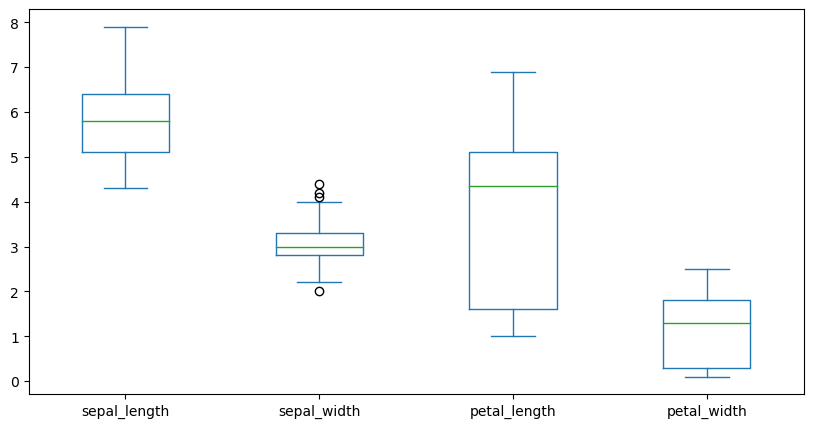

In [129]:
import matplotlib.pyplot as plt
X.plot(kind='box', figsize=(10, 5))
plt.show()

In [131]:
# rolling(n).mean()
X.rolling(5).mean().iloc[4:10]

,sepal_length,sepal_width,petal_length,petal_width
4,4.86,3.28,1.40,0.20
5,4.92,3.36,1.46,0.24
6,4.86,3.44,1.46,0.26
7,4.92,3.48,1.50,0.26
8,4.88,3.44,1.48,0.26
9,4.86,3.34,1.50,0.24


## 8.2 요약 통계량

- 기본값 : 숫자형(Numeric) 데이터를 가진 컬럼의 요약 통계량만 출력함.
    - 개수, 평균, 표준편차, 최솟값, 사분위수[Q1, Q2, Q3], 최댓값

In [132]:
# 1) 기본 요약 통계량
iris.describe() # 기본값 : 숫자열 데이터를 가진 컬럼에서의 요약 통계량

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [134]:
# 문자열/boolean 데이터를 가진 컬럼에서의 요약 통계량
# count-데이터 개수, unique-데이터 종류 수, top-최빈값(가장 흔한 값), freq-최빈값의 빈도수
iris['species'].describe()

count        150
unique         3
top       setosa
freq          50
Name: species, dtype: object

In [135]:
# 2) describe()의 include와 exclude
df = pd.DataFrame({'a':[1,2,3]*2,
                  'b':[1.1,2]*3,
                  'c':['aaa','bbb','aaa','ccc','aaa','bbb'],
                  'd':[True, False]*3})
display(df)
df.info()

,a,b,c,d
0,1,1.1,aaa,True
1,2,2.0,bbb,False
2,3,1.1,aaa,True
3,1,2.0,ccc,False
4,2,1.1,aaa,True
5,3,2.0,bbb,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a       6 non-null      int64  
 1   b       6 non-null      float64
 2   c       6 non-null      object 
 3   d       6 non-null      bool   
dtypes: bool(1), float64(1), int64(1), object(1)
memory usage: 278.0+ bytes


In [137]:
# include 매개변수 : 요약 통계량의 출력(포함)할 타입 지정 2
# 특정 타입 출력
df.describe(include=['int64', 'float64', 'bool'])

,a,b,d
count,6.000000,6.00000,6
unique,NaN,NaN,2
top,NaN,NaN,True
freq,NaN,NaN,3
mean,2.000000,1.55000,NaN
std,0.894427,0.49295,NaN
min,1.000000,1.10000,NaN
25%,1.250000,1.10000,NaN
50%,2.000000,1.55000,NaN
75%,2.750000,2.00000,NaN


In [142]:
# include 매개변수 : 요약 통계량의 출력(포함)할 타입 지정 2
# 모든 타입 출력
df.describe(include='all')

,a,b,c,d
count,6.000000,6.00000,6,6
unique,NaN,NaN,3,2
top,NaN,NaN,aaa,True
freq,NaN,NaN,3,3
mean,2.000000,1.55000,NaN,NaN
std,0.894427,0.49295,NaN,NaN
min,1.000000,1.10000,NaN,NaN
25%,1.250000,1.10000,NaN,NaN
50%,2.000000,1.55000,NaN,NaN
75%,2.750000,2.00000,NaN,NaN


In [139]:
# exclude 매개변수 : 요약 통계량의 제외할 타입 지정
df.describe(exclude='float64')

,a,c,d
count,6.000000,6,6
unique,NaN,3,2
top,NaN,aaa,True
freq,NaN,3,3
mean,2.000000,NaN,NaN
std,0.894427,NaN,NaN
min,1.000000,NaN,NaN
25%,1.250000,NaN,NaN
50%,2.000000,NaN,NaN
75%,2.750000,NaN,NaN


In [143]:
# 특정 컬럼의 고유 값들
df['c'].unique()

array(['aaa', 'bbb', 'ccc'], dtype=object)

In [147]:
# 특정 컬럼의 고유 값들의 개수 (내림차순)
df['c'].value_counts()
'''
- normalize=True : 개수 대신 '비율(Percentage)'로 출력 (0~1 사이 값)
- dropna=False   : 결측치(NaN)가 있다면 생략하지 않고 개수를 함께 표시함
- ascending=True : 빈도수가 적은 순서(오름차순)로 정렬함
'''

aaa    3
bbb    2
ccc    1
Name: c, dtype: int64

In [148]:
# 특정 타입의 컬럼만 추출
df.select_dtypes(include=object)

,c
0,aaa
1,bbb
2,aaa
3,ccc
4,aaa
5,bbb


In [150]:
# 특정 타입의 컬럼만 제외하여 추출
df.select_dtypes(exclude=[bool, object])

,a,b
0,1,1.1
1,2,2.0
2,3,1.1
3,1,2.0
4,2,1.1
5,3,2.0


## 8.3 공분산, 상관계수
- 공분산
    - 두 변수(X, Y)의 공분산 : $Cov(X, Y) = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{n - 1}$

    - $\bar{X}, \bar{Y}$: 각 변수의 평균

    - df.cov() : 한 변수가 변할 때 다른 변수가 어떻게 변하는지 나타내는 척도
    
- 상관계수
    - 두 변수(X, Y)의 상관계수 : $\mathbf{-1 \le \frac{Cov(X, Y)}{\sigma_X \cdot \sigma_Y} \le 1}$
    - $\sigma_X \cdot \sigma_Y$ : 자체적으로 흩어진 정도
    - df.corr() : 공분산을 각 변수의 표준편차로 나누어 -1과 1 사이의 값으로 표준화

In [152]:
# 공분산
X.cov()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


In [153]:
# 상관계수
X.corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


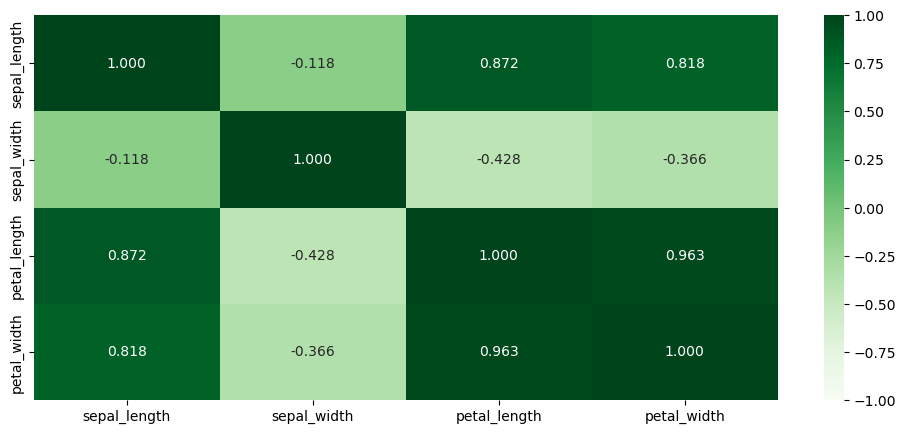

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))
sns.heatmap(X.corr(), annot=True, vmin=-1, vmax=1,cmap='Greens',fmt='.3f')
plt.show()